In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline


In [2]:
data=pd.read_csv("/content/Algerian_forest_fires_dataset.csv")

In [3]:
data.head(10)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
5,6,6,2012,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire
6,7,6,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire
7,8,6,2012,30,73,15,0,86.6,12.1,38.3,5.6,13.5,7.1,fire
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire
9,10,6,2012,28,79,12,0,73.2,9.5,46.3,1.3,12.6,0.9,not fire


In [4]:
len(data.columns)
data.columns


Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


Its a really good dataset and i can see that removing nulls would certainly not affect it much

I also see a classification of fire so we are detecting a fire hazard based on sensor output

In [6]:
data=data.dropna()

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          244 non-null    object
 1   month        244 non-null    object
 2   year         244 non-null    object
 3   Temperature  244 non-null    object
 4    RH          244 non-null    object
 5    Ws          244 non-null    object
 6   Rain         244 non-null    object
 7   FFMC         244 non-null    object
 8   DMC          244 non-null    object
 9   DC           244 non-null    object
 10  ISI          244 non-null    object
 11  BUI          244 non-null    object
 12  FWI          244 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 28.6+ KB


#From Kaggel:

RH: Relative Humidity


Ws: Wind SPeed


FFMC: Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5

DMC: Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9

DC:Drought Code (DC) index from the FWI system: 7 to 220.4

In [8]:
#conversions
data.columns = data.columns.str.strip()
cols = data.drop(columns=["Classes"],axis=1)

In [9]:
data = data.drop(data.index[122])

In [10]:
data["Classes"]=data["Classes"].apply(lambda x: x.strip())

In [11]:
for col in cols:
    data[col] = pd.to_numeric(data[col])

In [12]:
cols = data.drop(columns=["Classes"],axis=1)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 28.5+ KB


/tmp/ipykernel_427/1625828885.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Temperature'])


<Axes: xlabel='Temperature', ylabel='Density'>

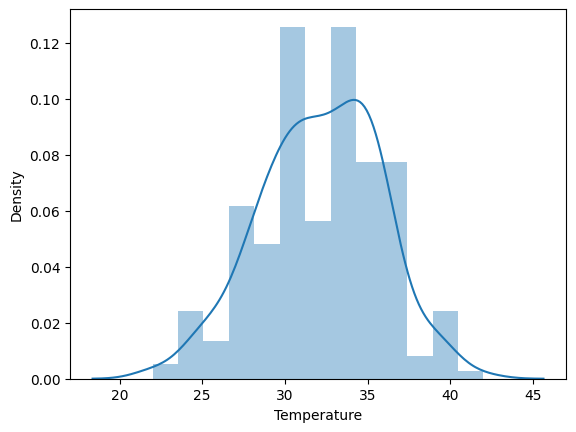

In [14]:
#temperature seems to have a good relation
sns.distplot(data['Temperature'])


In [15]:
data['year'].unique() #only one year's data
data=data.drop(columns='year',axis=1)

In [16]:

data['month'].unique() #months of june,july,august and september
data.head(10)

,day,month,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,5,6,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire
5,6,6,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire
6,7,6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,fire
7,8,6,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,fire
8,9,6,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire
9,10,6,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,not fire


In [17]:
data["Temperature"].value_counts()

,count
Temperature,
35,29
31,25
34,24
33,23
30,22
36,21
32,21
29,18
28,15


<Axes: >

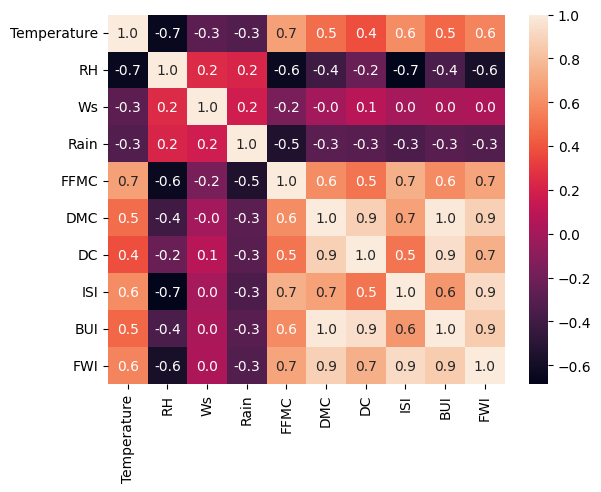

In [18]:
cols=cols.drop(columns=["day",'month','year'],axis=1)
corr=cols.corr()
sns.heatmap(corr,annot=True,fmt=".01f")
#everything is related
#i wanna take the gamble that if everything is related then nothing is

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
cols.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI'],
      dtype='object')

In [21]:
x=data[cols.columns]
y=data['Classes']

In [22]:
y=y.apply(lambda x: 1 if x=="fire" else 0)

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
l=model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score
print(accuracy_score(y_test,l))
print(confusion_matrix(y_test,l))
print(f1_score(y_test,l))
print(recall_score(y_test,l))
print(precision_score(y_test,l))

0.9795918367346939
[[23  0]
 [ 1 25]]
0.9803921568627451
0.9615384615384616
1.0


Everything is pretty good, now lets try other ones

But i just know this one is overfitted

In [26]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(x_train,y_train)
svc.score(x_test,y_test)
s=svc.predict(x_test)

In [27]:
print(accuracy_score(y_test,s))
print(confusion_matrix(y_test,s))
print(f1_score(y_test,s))
print(recall_score(y_test,s))
print(precision_score(y_test,s))

0.9591836734693877
[[22  1]
 [ 1 25]]
0.9615384615384616
0.9615384615384616
0.9615384615384616


In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svp=make_pipeline(StandardScaler(),SVC())
svp.fit(x_train,y_train)
svp.score(x_test,y_test)
ss=svp.predict(x_test)

In [29]:
print(accuracy_score(y_test,ss))
print(confusion_matrix(y_test,ss))
print(f1_score(y_test,ss))
print(recall_score(y_test,ss))
print(precision_score(y_test,ss))

0.9183673469387755
[[22  1]
 [ 3 23]]
0.92
0.8846153846153846
0.9583333333333334


Bruh went down

In [30]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf.score(x_test,y_test)
r=rf.predict(x_test)

In [31]:
print(accuracy_score(y_test,r))
print(confusion_matrix(y_test,r))
print(f1_score(y_test,r))
print(recall_score(y_test,r))
print(precision_score(y_test,r))

0.9795918367346939
[[23  0]
 [ 1 25]]
0.9803921568627451
0.9615384615384616
1.0


In [32]:
import joblib

joblib.dump(rf, "Logistic.pkl")

['Logistic.pkl']

#Testing


In [33]:
cols.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4


In [35]:
'''def inter():
    t = float(input("Temperature: "))
    rh = float(input("Relative Humidity: "))
    ws = float(input("Wind Speed: "))
    rain = float(input("Rain: "))
    ffmc = float(input("Fine Fuel Moisture Code: "))
    dmc = float(input("Duff Moisture Code: "))
    dc = float(input("Drought Code: "))
    isi = float(input("Initial Spread Index: "))
    bui = float(input("Buildup Index: "))
    fwi = float(input("Fire Weather Index: "))

    fire = input("Is there a fire? Y/N: ")
    actual = 1 if fire.upper() == "Y" else 0

    data = [[t, rh, ws, rain, ffmc, dmc, dc, isi, bui, fwi]]

    return data, actual


def turner(x):
    if x == 1:
        return "Fire"
    else:
        return "Not Fire"


print("Enter your input")

X, actual = inter()

prediction = rf.predict(X)[0]

print(
    "Predicted Value:", turner(prediction),
    "\nActual Value:", turner(actual)
)'''

'def inter():\n    t = float(input("Temperature: "))\n    rh = float(input("Relative Humidity: "))\n    ws = float(input("Wind Speed: "))\n    rain = float(input("Rain: "))\n    ffmc = float(input("Fine Fuel Moisture Code: "))\n    dmc = float(input("Duff Moisture Code: "))\n    dc = float(input("Drought Code: "))\n    isi = float(input("Initial Spread Index: "))\n    bui = float(input("Buildup Index: "))\n    fwi = float(input("Fire Weather Index: "))\n\n    fire = input("Is there a fire? Y/N: ")\n    actual = 1 if fire.upper() == "Y" else 0\n\n    data = [[t, rh, ws, rain, ffmc, dmc, dc, isi, bui, fwi]]\n\n    return data, actual\n\n\ndef turner(x):\n    if x == 1:\n        return "Fire"\n    else:\n        return "Not Fire"\n\n\nprint("Enter your input")\n\nX, actual = inter()\n\nprediction = rf.predict(X)[0]\n\nprint(\n    "Predicted Value:", turner(prediction),\n    "\nActual Value:", turner(actual)\n)'

Over FItted Model

#What did I Learn?

Using an overfitted model would cause a glitch in the working, so its better label a dataset usable i should accept that his correlation detoriorates a dataset


In [36]:
cols

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5
...,...,...,...,...,...,...,...,...,...,...
242,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5
243,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0
244,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2
245,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7


<Axes: >

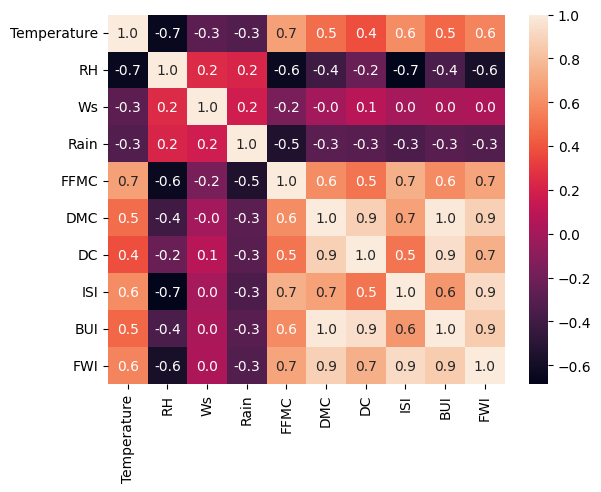

In [37]:
corr=cols.corr()
sns.heatmap(corr,annot=True,fmt="0.1f")
#Ws, Rain, Rh is only usable after all

In [38]:
cols=cols.drop(columns=["Temperature","FFMC","DMC","DC","ISI","BUI","FWI"])

In [39]:
cols

,RH,Ws,Rain
0,57,18,0.0
1,61,13,1.3
2,82,22,13.1
3,89,13,2.5
4,77,16,0.0
...,...,...,...
242,65,14,0.0
243,87,15,4.4
244,87,29,0.5
245,54,18,0.1


In [40]:
x=data[cols.columns]
y=data['Classes']
y=y.apply(lambda x: 1 if x=="fire" else 0)

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
l=model.predict(X_test_scaled)

In [42]:
print(accuracy_score(y_test,l))
print(confusion_matrix(y_test,l))
print(f1_score(y_test,l))
print(recall_score(y_test,l))
print(precision_score(y_test,l))

0.8775510204081632
[[17  6]
 [ 0 26]]
0.896551724137931
1.0
0.8125


Low efficacy

In [43]:
svc=SVC()
svc.fit(x_train,y_train)
svc.score(x_test,y_test)
s=svc.predict(x_test)

In [44]:
print(accuracy_score(y_test,s))
print(confusion_matrix(y_test,s))
print(f1_score(y_test,s))
print(recall_score(y_test,s))
print(precision_score(y_test,s))


0.7346938775510204
[[14  9]
 [ 4 22]]
0.7719298245614035
0.8461538461538461
0.7096774193548387


Even worse

In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svp=make_pipeline(StandardScaler(),SVC())
svp.fit(x_train,y_train)
svp.score(x_test,y_test)
ss=svp.predict(x_test)

In [46]:
print(accuracy_score(y_test,ss))
print(confusion_matrix(y_test,ss))
print(f1_score(y_test,ss))
print(recall_score(y_test,ss))
print(precision_score(y_test,ss))

0.8775510204081632
[[18  5]
 [ 1 25]]
0.8928571428571429
0.9615384615384616
0.8333333333333334


In [47]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf.score(x_test,y_test)
r=rf.predict(x_test)

In [48]:
print(accuracy_score(y_test,r))
print(confusion_matrix(y_test,r))
print(f1_score(y_test,r))
print(recall_score(y_test,r))
print(precision_score(y_test,r))

0.8367346938775511
[[19  4]
 [ 4 22]]
0.8461538461538461
0.8461538461538461
0.8461538461538461


In [49]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose =3) #verbose is necessary for study here
grid.fit(x_train, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.564 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.564 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.564 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.590 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.579 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.564 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.564 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.564 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.590 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.579 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.641 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [50]:
grid.best_estimator_

SVC(C=1000, gamma=0.01)

In [52]:
s=SVC(C=1000,gamma=0.01,kernel="rbf")
s.fit(x_train,y_train)
s.score(x_test,y_test)
ss=s.predict(x_test)
print(accuracy_score(y_test,ss))
print(confusion_matrix(y_test,ss))
print(f1_score(y_test,ss))
print(recall_score(y_test,ss))
print(precision_score(y_test,ss))

0.8163265306122449
[[16  7]
 [ 2 24]]
0.8421052631578947
0.9230769230769231
0.7741935483870968


Diabolical

So i am going for untuned SVC

In [53]:
import joblib
joblib.dump(s,"SVC.pkl")

['SVC.pkl']

In [59]:
def inter():

    rh = float(input("Relative Humidity: "))
    ws = float(input("Wind Speed: "))
    rain = float(input("Rain: "))

    fire = input("Is there a fire? Y/N: ")
    actual = 1 if fire.upper() == "Y" else 0

    data = [[rh, ws, rain]]

    return data, actual


def turner(x):
    if x == 1:
        return "Fire"
    else:
        return "Not Fire"


print("Enter your input")

X, actual = inter()

prediction = s.predict(X)[0]

print(
    "Predicted Value:", turner(prediction),
    "\nActual Value:", turner(actual)
)

Enter your input
Relative Humidity: 31
Wind Speed: 24
Rain: 0.0
Is there a fire? Y/N: Y
Predicted Value: Fire 
Actual Value: Fire


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Still

I will say way too less relationship markers so, some relationships could have helped